<a href="https://colab.research.google.com/github/Alister44/DTA_2026_DE/blob/main/sales_store_analysis/sales_store_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Verkaufsanalyse eines Geschäfts


# Eingangsdatensatz (Daten)


In [1]:
# Führe diesen Block aus, um den Datensatz zu erhalten
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

categories = ['Molkereiprodukte', 'Brot und Backwaren', 'Fleisch und Fisch', 'Obst und Gemuese', 'Getraenke']
products = {
    'Molkereiprodukte':   ['Milch 1L', 'Kefir 0.5L', 'Quark', 'Butter', 'Joghurt'],
    'Brot und Backwaren': ['Weissbrot', 'Baguette', 'Broetchen', 'Roggenbrot', 'Croissant'],
    'Fleisch und Fisch':  ['Haehnchenfilet', 'Schweinefleisch', 'Wurst', 'Seelachs', 'Wuerstchen'],
    'Obst und Gemuese':   ['Kartoffeln', 'Karotten', 'Aepfel', 'Bananen', 'Tomaten'],
    'Getraenke':          ['Wasser 1.5L', 'Orangensaft', 'Tee', 'Gemahlener Kaffee', 'Limonade'],
}
prices = {
    'Milch 1L': 1.15, 'Kefir 0.5L': 1.20, 'Quark': 1.50, 'Butter': 2.30, 'Joghurt': 0.85,
    'Weissbrot': 1.80, 'Baguette': 1.50, 'Broetchen': 0.40, 'Roggenbrot': 2.20, 'Croissant': 1.10,
    'Haehnchenfilet': 6.50, 'Schweinefleisch': 8.90, 'Wurst': 4.50, 'Seelachs': 5.20, 'Wuerstchen': 3.80,
    'Kartoffeln': 1.20, 'Karotten': 0.90, 'Aepfel': 2.20, 'Bananen': 1.80, 'Tomaten': 2.90,
    'Wasser 1.5L': 0.65, 'Orangensaft': 2.50, 'Tee': 3.20, 'Gemahlener Kaffee': 5.90, 'Limonade': 1.40,
}

chosen_cats = np.random.choice(categories, n, p=[0.25, 0.20, 0.20, 0.20, 0.15])
chosen_products = [np.random.choice(products[c]) for c in chosen_cats]

df_origin = pd.DataFrame({
    'transaction_id': range(1001, 1001 + n),
    'date':           pd.to_datetime(
                          np.random.choice(pd.date_range('2024-03-01', '2024-03-31'), n)
                      ),
    'hour':           np.random.choice(range(8, 21), n, p=[0.04,0.06,0.08,0.10,0.12,0.12,0.11,0.10,0.09,0.08,0.06,0.04,0.00]),
    'category':       chosen_cats,
    'product':        chosen_products,
    'quantity':       np.random.randint(1, 6, n),
    'price_eur':      [prices[p] for p in chosen_products],
    'customer_age':   np.random.randint(18, 70, n),
    'payment':        np.random.choice(['Bargeld', 'Karte', 'Telefon'], n, p=[0.35, 0.50, 0.15]),
})




In [2]:
df = df_origin.copy()
df

,transaction_id,date,hour,category,product,quantity,price_eur,customer_age,payment
0,1001,2024-03-17,17,Brot und Backwaren,Croissant,4,1.10,28,Bargeld
1,1002,2024-03-13,14,Getraenke,Gemahlener Kaffee,3,5.90,40,Karte
2,1003,2024-03-01,18,Obst und Gemuese,Aepfel,1,2.20,43,Karte
3,1004,2024-03-02,8,Fleisch und Fisch,Seelachs,3,5.20,51,Bargeld
4,1005,2024-03-09,19,Molkereiprodukte,Joghurt,5,0.85,63,Karte
...,...,...,...,...,...,...,...,...,...
295,1296,2024-03-08,10,Fleisch und Fisch,Wuerstchen,4,3.80,48,Bargeld
296,1297,2024-03-05,13,Obst und Gemuese,Karotten,5,0.90,28,Telefon
297,1298,2024-03-04,11,Molkereiprodukte,Milch 1L,3,1.15,27,Karte
298,1299,2024-03-24,14,Fleisch und Fisch,Wurst,1,4.50,20,Bargeld


Block 1 - Erster Blick auf die Daten


Gib die ersten 7 Zeilen des DataFrames aus.


In [3]:
df.head(7)

,transaction_id,date,hour,category,product,quantity,price_eur,customer_age,payment
0,1001,2024-03-17,17,Brot und Backwaren,Croissant,4,1.10,28,Bargeld
1,1002,2024-03-13,14,Getraenke,Gemahlener Kaffee,3,5.90,40,Karte
2,1003,2024-03-01,18,Obst und Gemuese,Aepfel,1,2.20,43,Karte
3,1004,2024-03-02,8,Fleisch und Fisch,Seelachs,3,5.20,51,Bargeld
4,1005,2024-03-09,19,Molkereiprodukte,Joghurt,5,0.85,63,Karte
5,1006,2024-03-03,13,Molkereiprodukte,Kefir 0.5L,3,1.20,51,Karte
6,1007,2024-03-31,15,Molkereiprodukte,Butter,2,2.30,46,Telefon


In [4]:
print(df.head(7))

   transaction_id       date  hour            category            product  \
0            1001 2024-03-17    17  Brot und Backwaren          Croissant   
1            1002 2024-03-13    14           Getraenke  Gemahlener Kaffee   
2            1003 2024-03-01    18    Obst und Gemuese             Aepfel   
3            1004 2024-03-02     8   Fleisch und Fisch           Seelachs   
4            1005 2024-03-09    19    Molkereiprodukte            Joghurt   
5            1006 2024-03-03    13    Molkereiprodukte         Kefir 0.5L   
6            1007 2024-03-31    15    Molkereiprodukte             Butter   

   quantity  price_eur  customer_age  payment  
0         4       1.10            28  Bargeld  
1         3       5.90            40    Karte  
2         1       2.20            43    Karte  
3         3       5.20            51  Bargeld  
4         5       0.85            63    Karte  
5         3       1.20            51    Karte  
6         2       2.30            46  Telefon  

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  300 non-null    int64         
 1   date            300 non-null    datetime64[ns]
 2   hour            300 non-null    int64         
 3   category        300 non-null    object        
 4   product         300 non-null    object        
 5   quantity        300 non-null    int64         
 6   price_eur       300 non-null    float64       
 7   customer_age    300 non-null    int64         
 8   payment         300 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 21.2+ KB


In [6]:
df['total_eur'] = df.quantity * df.price_eur

Finde die Größe der Tabelle heraus (Zeilen × Spalten).


In [7]:
print(f"Size: {df.shape[0]} - rows,{df.shape[1]} -columns ")

Size: 300 - rows,10 -columns 


Gib die Datentypen jeder Spalte aus.


In [8]:
print("Data types: ")
display(df.dtypes)

Data types: 


,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_eur,float64
customer_age,int64
payment,object
total_eur,float64


Prüfe, ob es fehlende Werte gibt.


In [9]:
df.isna()

,transaction_id,date,hour,category,product,quantity,price_eur,customer_age,payment,total_eur
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False,False


In [10]:
print(f"Fehlende Werte pro Spalte {df.isnull().sum()}")


Fehlende Werte pro Spalte transaction_id    0
date              0
hour              0
category          0
product           0
quantity          0
price_eur         0
customer_age      0
payment           0
total_eur         0
dtype: int64


Gib die grundlegende Statistik (describe) für die numerischen Spalten aus.


In [11]:
print("Statistik: \n")
df.describe().round(2)


Statistik: 



,transaction_id,date,hour,quantity,price_eur,customer_age,total_eur
count,300.00,300,300.00,300.00,300.00,300.0,300.00
mean,1150.50,2024-03-16 02:14:24,13.72,2.97,2.55,43.0,7.55
min,1001.00,2024-03-01 00:00:00,8.00,1.00,0.40,18.0,0.40
25%,1075.75,2024-03-08 00:00:00,12.00,2.00,1.15,31.0,2.55
50%,1150.50,2024-03-16 12:00:00,14.00,3.00,1.80,42.5,4.80
75%,1225.25,2024-03-24 00:00:00,16.00,4.00,3.35,55.0,9.30
max,1300.00,2024-03-31 00:00:00,19.00,5.00,8.90,69.0,35.60
std,86.75,NaN,2.74,1.44,2.00,14.6,7.12


In [12]:
s = [1, 7, 9, 10, 12, 15, 20]
mean = sum(s)/len(s)
mean
s = [1, 1, 1, 1, 1, 1, 1000]
mean = sum(s)/len(s)
mean
# std -> 143.71 - 1 = 142.71
mediana = 1

**Schlussfolgerung**  
Der Datensatz enthält Informationen zu 300 Transaktionen  
Durchschnittlicher Bonbetrag - 7.55 €  
Minimaler Bon - 0.40 €  
Maximaler Bon - 35.60 €


# Block 2 - Filterung und Auswahl


Wähle alle Käufe der Kategorie „Fleisch und Fisch" aus.


In [13]:
# Aufgabe:
df[df["category"] == "Fleisch und Fisch"].head()


,transaction_id,date,hour,category,product,quantity,price_eur,customer_age,payment,total_eur
3,1004,2024-03-02,8,Fleisch und Fisch,Seelachs,3,5.2,51,Bargeld,15.6
8,1009,2024-03-21,15,Fleisch und Fisch,Wurst,2,4.5,34,Karte,9.0
17,1018,2024-03-06,14,Fleisch und Fisch,Haehnchenfilet,3,6.5,69,Karte,19.5
20,1021,2024-03-23,9,Fleisch und Fisch,Haehnchenfilet,3,6.5,64,Telefon,19.5
24,1025,2024-03-10,14,Fleisch und Fisch,Schweinefleisch,4,8.9,28,Karte,35.6


In [14]:
meat_fish = df[df["category"] == "Fleisch und Fisch"]
print(f"In der Kategorie Fleisch und Fisch gibt es {len(meat_fish)} Transaktionen")


In der Kategorie Fleisch und Fisch gibt es 61 Transaktionen


Finde Transaktionen, bei denen der Betrag (total_eur) 20 € übersteigt.



In [15]:
big = df[df['total_eur'] > 20]
print(f"Käufe über 20 € - {len(big)}")
print(big[['product','quantity','total_eur']].head())


Käufe über 20 € - 20
            product  quantity  total_eur
24  Schweinefleisch         4       35.6
28   Haehnchenfilet         4       26.0
48         Seelachs         4       20.8
89         Seelachs         5       26.0
93  Schweinefleisch         3       26.7


In [16]:
big.category.unique()

array(['Fleisch und Fisch', 'Getraenke'], dtype=object)

In [17]:
for cat in big.category.unique():
    print(f"{cat} - {big['category'].count()}")

Fleisch und Fisch - 20
Getraenke - 20


In [18]:
# Prozentsatz der großen Käufe
pct_big = len(big) / len(df) * 100
round(pct_big,2)
print(f"Anteil der Käufe > 20 €: {pct_big:.1f}")


Anteil der Käufe > 20 €: 6.7


Wähle Käufe aus, die mit Karte bezahlt wurden (payment == 'Karte'), mit einer Menge über 2 Einheiten.


In [19]:
card_mult = df[(df['payment'] == 'Karte') & (df['quantity'] > 2)]
print("Karte + Menge > 2: ",len(card_mult))


Karte + Menge > 2:  92


Finde alle Käufe von Kunden unter 25 Jahren.


In [20]:
young = df[df['customer_age'] < 25]
print(f"Kunden unter 25 Jahren: {len(young)}")


Kunden unter 25 Jahren: 36


Wie viele eindeutige Produkte gibt es im Datensatz?


In [21]:
n_unique = df['product'].nunique() #Anzahl der eindeutigen Produkte
n_unique


25

In [22]:
pr_unique = df['product'].unique() #Liste der eindeutigen Produkte
pr_unique


array([np.str_('Croissant'), np.str_('Gemahlener Kaffee'),
       np.str_('Aepfel'), np.str_('Seelachs'), np.str_('Joghurt'),
       np.str_('Kefir 0.5L'), np.str_('Butter'), np.str_('Orangensaft'),
       np.str_('Wurst'), np.str_('Kartoffeln'), np.str_('Quark'),
       np.str_('Karotten'), np.str_('Haehnchenfilet'),
       np.str_('Roggenbrot'), np.str_('Baguette'), np.str_('Weissbrot'),
       np.str_('Schweinefleisch'), np.str_('Wuerstchen'),
       np.str_('Milch 1L'), np.str_('Tomaten'), np.str_('Limonade'),
       np.str_('Broetchen'), np.str_('Bananen'), np.str_('Wasser 1.5L'),
       np.str_('Tee')], dtype=object)

## Schlussfolgerung  
Etwa die Hälfte der Käufe wird mit Karte bezahlt, davon hat ein Drittel mehr als 2 Produkte im Bon.  
6,7% der Transaktionen überschreiten einen Bon von 20 €, meistens in der Kategorie „Fleisch und Fisch"  


12% der Kunden sind unter 25 Jahren


# Block 3 - Gruppierung und Aggregation


Berechne den Gesamtumsatz für jede Kategorie. Sortiere absteigend.


In [23]:
revenue_by_cat = df.groupby('category')['total_eur'].sum().sort_values(ascending=False)
revenue_by_cat


,total_eur
category,
Fleisch und Fisch,1009.50
Getraenke,393.45
Molkereiprodukte,312.00
Obst und Gemuese,294.60
Brot und Backwaren,256.20


In [24]:
df.groupby('category').agg(
    {'total_eur':'sum',
    'quantity': 'sum',
     'transaction_id': 'count',
     'quantity':'sum'}
).sort_values(by=['total_eur','transaction_id'],ascending = False)


,total_eur,quantity,transaction_id
category,,,
Fleisch und Fisch,1009.50,186,61
Getraenke,393.45,129,48
Molkereiprodukte,312.00,242,80
Obst und Gemuese,294.60,158,55
Brot und Backwaren,256.20,177,56


Finde die Top-5-Produkte nach Anzahl der verkauften Einheiten (Summe von quantity).


In [25]:

print("TOP 5 Produkte nach Anzahl der verkauften Einheiten ")
#top_products =
df.groupby('product')['quantity'].sum().sort_values(ascending = False).head()


TOP 5 Produkte nach Anzahl der verkauften Einheiten 


,quantity
product,
Kefir 0.5L,63
Wuerstchen,61
Joghurt,57
Quark,54
Seelachs,48


Vergleiche den durchschnittlichen Kaufbetrag für verschiedene Zahlungsmethoden.


In [26]:
df.groupby("payment")["total_eur"].mean().round(2)

,total_eur
payment,
Bargeld,6.98
Karte,8.29
Telefon,6.09


Gruppiere nach hour - finde heraus, in welchen Stunden die meisten Transaktionen stattfinden.


In [27]:
df.groupby('hour').size()

,0
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [28]:
df.groupby('hour')['hour'].count()

,hour
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [29]:
print("Transaktionen nach Stunden")
df["hour"].value_counts()


Transaktionen nach Stunden


,count
hour,
14,44
13,41
16,32
12,30
11,30
15,27
17,26
10,23
18,19


Finde den Tag des Monats mit dem höchsten Umsatz.


In [30]:
df['date'].dt.day

,date
0,17
1,13
2,1
3,2
4,9
...,...
295,8
296,5
297,4
298,24


In [31]:
df['day'] = df['date'].dt.day #erstellen eine neue Spalte für den Tag in der Tabelle
best_date = df.groupby('day')['total_eur'].sum().idxmax()
best_revenue = df.groupby('day')['total_eur'].sum().max()

print(f"Bester Tag {best_date}. März, {best_revenue:.2f} €")


Bester Tag 2. März, 130.35 €


In [32]:
df.groupby('day')['total_eur'].sum()


,total_eur
day,
1,52.80
2,130.35
3,96.35
4,64.30
5,104.85
6,105.65
7,34.50
8,69.10
9,61.55


Frage: Welche Kategorie bringt am meisten Geld ein? Was wird am häufigsten gekauft?


Profitabelste Kategorie - "Fleisch und Fisch" (hoher Preis)  
Am häufigsten werden Molkereiprodukte gekauft, besonders Kefir.  

Verkaufsspitzenzeiten von 13-14 Uhr, wobei der Kundenzuwachs schon ab 11 Uhr beginnt.  

Kunden, die per Karte bezahlen, haben im Durchschnitt einen höheren Bon als jene, die bar bezahlen.




# Block 4 - Neue Spalten und Transformation


Füge die Spalte revenue_share hinzu - der Anteil des Umsatzes jeder Transaktion am Gesamtumsatz (in Prozent).


In [33]:
total_revenue = df.total_eur.sum()
df['revenue_share'] = (df.total_eur / total_revenue * 100).round(4)
df[['product','total_eur','revenue_share']].head()


,product,total_eur,revenue_share
0,Croissant,4.40,0.1942
1,Gemahlener Kaffee,17.70,0.7812
2,Aepfel,2.20,0.0971
3,Seelachs,15.60,0.6885
4,Joghurt,4.25,0.1876


Füge die Spalte age_group hinzu:
'Jugend' - bis 30 Jahre  
'Mittleres Alter' - 30–50 Jahre  
'Ältere' - über 50 Jahre


In [34]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[0,30,50,100],
    labels=['Jugend','Mittleres Alter','Ältere'],
    right=False #[0-30) [30,50), [50,100)
)
print("Verteilung nach Altersgruppen ")
df.age_group.value_counts()


Verteilung nach Altersgruppen 


,count
age_group,
Mittleres Alter,120
Ältere,111
Jugend,69


Füge die Spalte weekday hinzu - der Wochentag aus der Spalte date.


In [35]:
df['weekday'] = df.date.dt.day_name()
df['weekday'].value_counts()

,count
weekday,
Sunday,55
Saturday,51
Friday,48
Tuesday,43
Wednesday,35
Monday,35
Thursday,33


Füge die boolesche Spalte is_big_purchase hinzu - True, wenn total_eur > 12.


In [36]:
df["is_big_purchase"] = df.total_eur > 12
df["is_big_purchase"]


,is_big_purchase
0,False
1,True
2,False
3,True
4,False
...,...
295,True
296,False
297,False
298,False


In [37]:
df["is_big_purchase"] = df.total_eur > 12
pct = df['is_big_purchase'].mean() * 100 #Trick, um den % der großen Käufe an der Gesamtzahl zu zählen
print(f" Anteil großer Käufe (>12€) {pct:.1f}%")



 Anteil großer Käufe (>12€) 18.3%


In [38]:
print("Durchschnittlicher Bon nach Altersgruppen, Anzahl großer Käufe")
df.groupby('age_group',observed=True).agg({
    'total_eur': "mean",
    'is_big_purchase':"sum"
}).round(2)


Durchschnittlicher Bon nach Altersgruppen, Anzahl großer Käufe


,total_eur,is_big_purchase
age_group,,
Jugend,6.23,9
Mittleres Alter,7.88,24
Ältere,8.02,22


# Block 5 Visualisierung


In [39]:
df.columns

Index(['transaction_id', 'date', 'hour', 'category', 'product', 'quantity',
       'price_eur', 'customer_age', 'payment', 'total_eur', 'day',
       'revenue_share', 'age_group', 'weekday', 'is_big_purchase'],
      dtype='object')

Füge jedem Diagramm einen Titel und Achsenbeschriftungen hinzu.

Balkendiagramm - Umsatz nach Kategorien.


In [40]:
import matplotlib.pyplot as plt

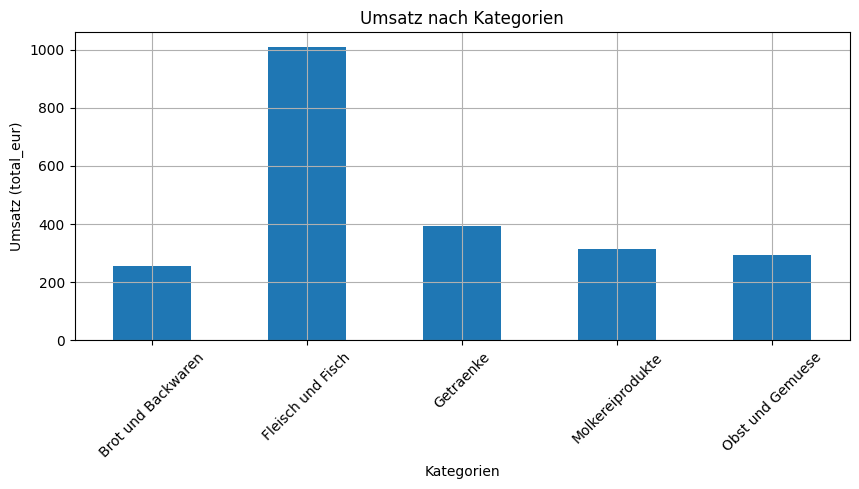

In [41]:


fig = plt.figure(figsize=(10,4))
#df.category.value_counts().plot(kind='bar')
df.groupby('category')['total_eur'].sum().plot(kind='bar')
plt.title("Umsatz nach Kategorien")
plt.xlabel("Kategorien")
plt.ylabel("Umsatz (total_eur)")
plt.xticks(rotation=45)
plt.grid()
plt.show()




Horizontales Balkendiagramm - Top-10-Produkte nach Umsatz.


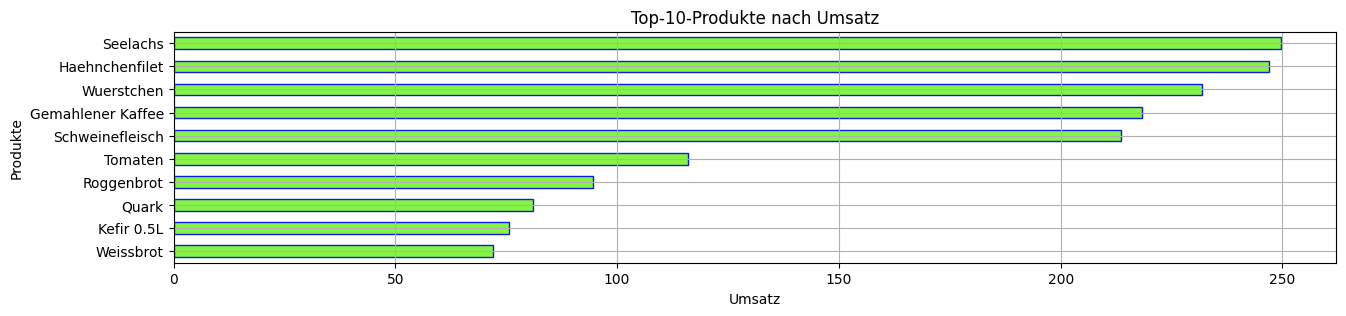

In [42]:
fig = plt.figure(figsize=(15,3))

top10_revenue = (
    df.groupby("product")['total_eur']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

top10_revenue.plot(
    kind='barh',
    color='#84f542',
    edgecolor="#0d1ce0"
)

plt.title('Top-10-Produkte nach Umsatz')
plt.xlabel('Umsatz')
plt.ylabel('Produkte')
plt.grid()
plt.show()


Kreisdiagramm - Verteilung der Zahlungsmethoden.


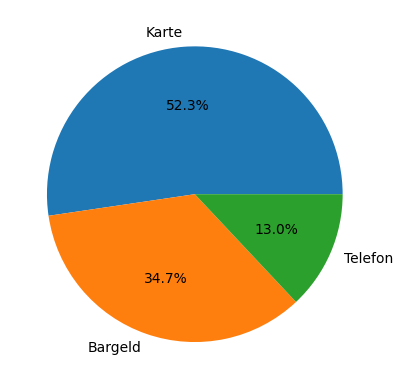

In [43]:
fig = plt.figure()
payment_count = df.payment.value_counts()
plt.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')

plt.show()

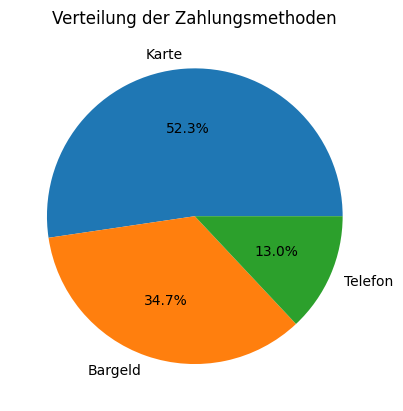

In [44]:
fig, ax = plt.subplots()
payment_count = df.payment.value_counts()
ax.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
ax.set_title('Verteilung der Zahlungsmethoden')
plt.show()


Liniendiagramm - Umsatz nach Tagen im März.


<Axes: xlabel='day'>

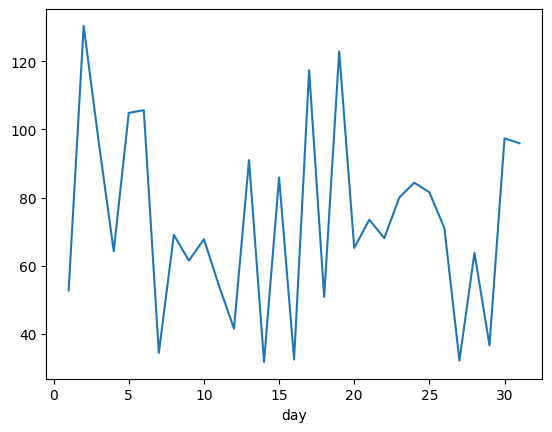

In [45]:
df.groupby('day')['total_eur'].sum().plot(kind='line')

In [46]:
df.groupby(['day','category'])['total_eur'].sum().unstack()

category,Brot und Backwaren,Fleisch und Fisch,Getraenke,Molkereiprodukte,Obst und Gemuese
day,,,,,
1,NaN,NaN,28.60,4.50,19.7
2,2.0,85.3,13.90,7.05,22.1
3,4.4,64.0,17.30,7.05,3.6
4,3.0,52.0,5.85,3.45,NaN
5,25.5,26.7,30.80,11.35,10.5
6,NaN,53.7,5.90,7.35,38.7
7,NaN,24.2,NaN,3.40,6.9
8,31.0,22.8,NaN,12.60,2.7
9,NaN,36.9,1.30,8.85,14.5


<Axes: xlabel='day'>

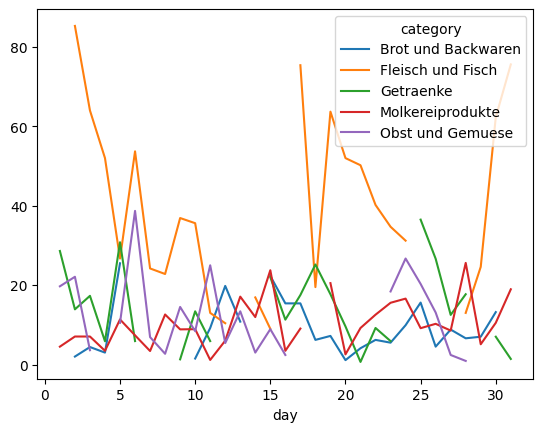

In [47]:
df.groupby(['day','category'])['total_eur'].sum().unstack().plot()

Histogramm - Verteilung von customer_age.


In [48]:
df.customer_age.value_counts()

,count
customer_age,
28,10
32,10
37,10
58,9
20,9
25,9
19,8
46,8
29,8


In [49]:
df['customer_age'].value_counts().mean()

np.float64(5.882352941176471)

[22. 14. 25. 20. 21. 24. 17. 21. 17. 22. 23. 20. 18. 16. 20.]
[18.  21.4 24.8 28.2 31.6 35.  38.4 41.8 45.2 48.6 52.  55.4 58.8 62.2
 65.6 69. ]
<BarContainer object of 15 artists>


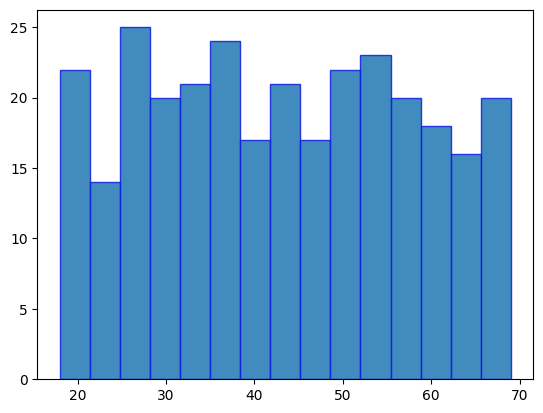

In [50]:
counts, bins, patches =  plt.hist(
    df['customer_age'],
    bins=15,
    edgecolor='#0d1ce0',
    alpha=0.85
)

print(counts)
print(bins)
print(patches)


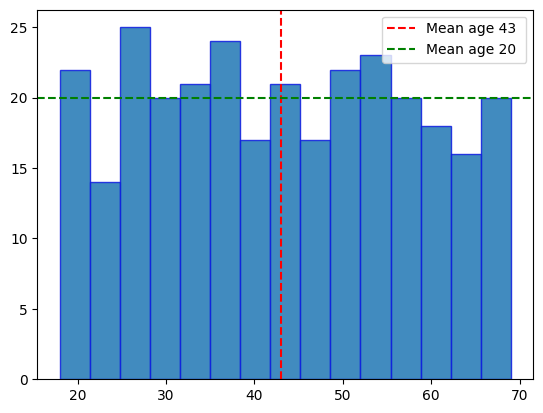

In [51]:
from matplotlib.lines import lineStyles
plt.hist(
    df['customer_age'],
    bins=15,
    edgecolor='#0d1ce0',
    alpha=0.85

)
plt.axvline(
    df['customer_age'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean age {df['customer_age'].mean():.0f} "
)
plt.axhline(
    counts.mean(),
    color='green',
    linestyle='--',
    label=f"Mean age {counts.mean():.0f} "
)
plt.legend()
plt.show()

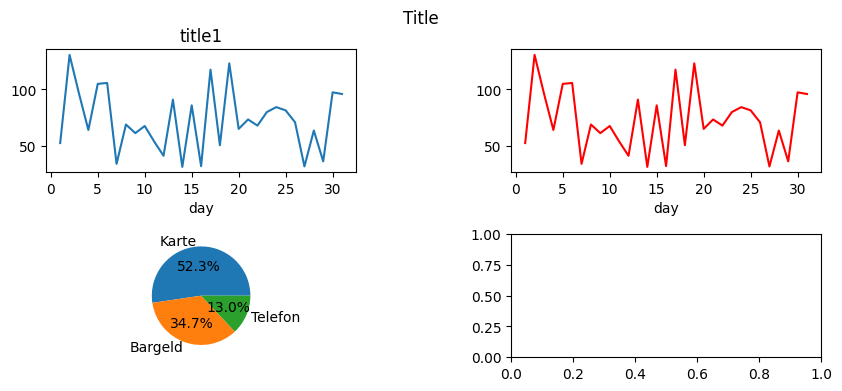

In [52]:
# plt.figure(figsize=(8, 3))
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
fig.suptitle("Title")
plt.subplots_adjust(hspace=0.5, wspace=0.5)

ax1 = axes[0, 0]
ax1.set_title("title1")
ax1.set_xlabel("bins age")
df.groupby('day')['total_eur'].sum().plot(kind='line', ax=ax1)
ax2 = axes[0, 1]
df.groupby('day')['total_eur'].sum().plot(kind='line', color="red", ax=ax2)
ax3 = axes[1, 0]
payment_count = df.payment.value_counts()
ax3.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
plt.savefig('figure.png')
plt.show()

Welche Produktkategorie ist am profitabelsten?   

Aus dem Histogramm des Umsatzes nach Kategorien sehen wir, dass die profitabelste Kategorie Fleisch und Fisch ist  

In welchen Stunden ist der Handel am aktivsten?
Um 14 und 13 Uhr findet der aktivste Handel statt, möglicherweise hängt das damit zusammen, dass Menschen in der Mittagspause einkaufen.  

Welche Zahlungsmethode überwiegt?  
Aus dem Diagramm sehen wir, dass die Zahlung per Karte überwiegt.  

Gibt es „Spitzentage" beim Verkauf?
Wer ist der typische Kunde (Alter, was er kauft, wie er bezahlt)?




In [53]:
print(f"Alter:{df_origin['customer_age'].median():.0f} Jahre")
print(f"Lieblingsprodukt:{df_origin['product'].value_counts().index[0]}")
print(f"Zahlungsmethode:{df_origin['payment'].value_counts().index[0]}")
print(f"Durchschnittlicher Bon: {(df_origin['quantity'] * df_origin['price_eur']).mean():.2f}")


Alter:42 Jahre
Lieblingsprodukt:Kefir 0.5L
Zahlungsmethode:Karte
Durchschnittlicher Bon: 7.55
